# <div style="text-align:center;">Running and Fine-Tuning a Large Language Model on Your Laptop</div>

## <div style="text-align:center;">Contents</div>

1) Introduction & setup  
2) Load GPT-2  
3) Core concepts  
4) Running inference  
5) Fine-tuning the model
6) Conclusion

## <div style="text-align:center;">1) Introduction</div>

### Motivation

<div style="text-align:center;font-size:1.2em;">Why run locally? </div>
<ul style="text-align:left;font-size:1.0em;">
<li>Privacy</li>
<li>No API cost</li>
<li>Complete control</li>
<li>It is fun!</li>
<li>Because you can!!!</li>
</ul>

### **G**enerative **P**re-trained **T**ransformer **2** (**GPT-2**) at a glance

<ul style="text-align:left;font-size:1.0em;">
<li>OpenAI's second major GPT language model</li>
<li>Released February 14th, 2019</li>
<li>It has 124 million parameters</li>
<li>Full model weights made public on November 5th, 2019</li>
<li>Trained on WebText data, 8 million documents, 40GB of text</li>
<li>Context Window: 1024 tokens</li> 
<li>Vocabulary Size 50,257 tokens</li>
<li>GPT-2 was released in four versions: small, medium, large and XL</li>
<li>This talk focuses GPT-2 small </li>
</ul>

### How does it compare to more recent models?

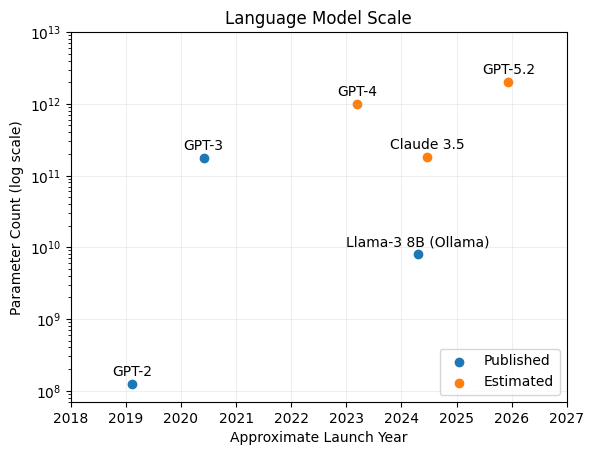

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("HF_HOME", os.path.expanduser("~/.cache/huggingface"))
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")
import pandas as pd
import matplotlib.pyplot as plt
scale_data = [("GPT-2", 124e6, 2019.12), ("GPT-3", 175e9, 2020.41), ("GPT-4", 1e12, 2023.20),
    ("Claude 3.5", 180e9, 2024.47), ("Llama-3 8B (Ollama)", 8e9, 2024.30), ("GPT-5.2", 2e12, 2025.94)]
df_scale = pd.DataFrame(scale_data, columns=["model", "params", "year"])
df_scale["estimated"] = df_scale["model"].isin(["GPT-4", "Claude 3.5", "GPT-5.2"])
for est, label in [(False, "Published"), (True, "Estimated")]:
    d = df_scale[df_scale["estimated"] == est]
    plt.scatter(d["year"], d["params"], label=label)
plt.yscale("log")
for _, row in df_scale.iterrows():
    plt.text(row["year"], row["params"] * 1.18, row["model"],
             ha="center", va="bottom")
plt.title("Language Model Scale")
plt.xlabel("Approximate Launch Year")
plt.ylabel("Parameter Count (log scale)")
plt.xlim(2018, 2027)
plt.ylim(7e7, 1e13)
plt.grid(True, alpha=0.2)
plt.legend(loc="lower right")
plt.show()

## <div style="text-align:center;">2) Load GPT-2</div>

### Python Imports

In [2]:
# imports
import os, sys, time, random, torch, transformers
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("HF_HOME", os.path.expanduser("~/.cache/huggingface"))
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")
os.environ.setdefault("HF_HUB_OFFLINE", "1")
import numpy as np, pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import logging

# Use CPU for a stable, reproducible laptop demo.
# You can switch this to "mps" for faster Apple Silicon inference,
# but small fine-tuning runs may vary or crash on some MPS setups.
DEVICE = "cpu"

# Fix random seeds to 42
torch.manual_seed(42); np.random.seed(42); random.seed(42)

# Environment info
print(f"Python: {sys.version.split()[0]} | Torch: {torch.__version__} | " 
      f"Transformers: {transformers.__version__} | Device: {DEVICE}")


Python: 3.12.4 | Torch: 2.4.1 | Transformers: 4.44.2 | Device: cpu


### Load the Model

In [3]:
MODEL_NAME = "gpt2"            # model to load (GPT-2 small, ~124M parameters)
logging.set_verbosity_error()  # avoid noisy network retries in offline demos
# load tokenizer (text ↔ token ids)
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, 
    clean_up_tokenization_spaces = False,     # preserve the exact token boundaries
    local_files_only=True,                    # use cached files; no network retries
)
tokenizer.pad_token = tokenizer.eos_token           # GPT-2 has no pad token → reuse EOS token
# load pretrained causal language model
#<<1>> FORCE WEIGHTS DOWNLOAD
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    force_download=True   # forces a fresh download
)
#<<2>> CACHED WEIGHTS 
#model = AutoModelForCausalLM.from_pretrained(
#    MODEL_NAME,
#    local_files_only=True,                    # use cached files; no network retries
#)
model.to(DEVICE) # run model on the selected device
model.eval()  # disable training layers (dropout)
print("Model Loaded:   ", MODEL_NAME)   # confirmation
# count total number of GPT-2 model parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"Number of GPT-2 Parameters: {n_params:,}")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model Loaded:    gpt2
Number of GPT-2 Parameters: 124,439,808


### Run a small prompt with the pretrained model

In [4]:
# simple text generation helper
def generate_text(prompt, max_new_tokens=10, temperature=0.8, top_k=40):
    model_device = next(model.parameters()).device
    encoded = tokenizer(prompt, return_tensors="pt").to(model_device)  # convert text to token ids

    input_ids = encoded["input_ids"]
    attention_mask = encoded["attention_mask"]

    with torch.no_grad():                                      # disable gradients
        for _ in range(max_new_tokens):
            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            ).logits[:, -1, :]

            if temperature <= 1e-4:
                next_id = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                top_values, top_indices = torch.topk(logits / temperature, k=top_k, dim=-1)
                probs = torch.softmax(top_values, dim=-1)
                sampled = torch.multinomial(probs, num_samples=1)
                next_id = top_indices.gather(-1, sampled)

            input_ids = torch.cat([input_ids, next_id], dim=1)
            attention_mask = torch.cat([attention_mask, torch.ones_like(next_id)], dim=1)

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)   # convert tokens to text

# example prompt
PROMPT = "The capital of Spain is"

# run model with prompt and time it
start = time.time(); text = generate_text(PROMPT); end = time.time()

# print result and timing
print("Prompt:", PROMPT)
print("Output:", text)
print(f"Time: {end - start:.2f}s ({next(model.parameters()).device})")


Prompt: The capital of Spain is
Output: The capital of Spain is Madrid. Its most famous historical site, Tá
Time: 0.49s (cpu)


### Run a small prompt many times!

In [5]:
print("Prompt:",PROMPT);  # run same prompt several times
for i in range(1,5) :
    print(f"Output {i:2}: {generate_text(PROMPT)}")
print();  # separation line
print("Prompt:",PROMPT);  # run same prompt several times
for i in range(1,5) :
    print(f"Output {i:2}: {generate_text(PROMPT,temperature=0.00001)}")


Prompt: The capital of Spain is
Output  1: The capital of Spain is home to the world's oldest and largest population of
Output  2: The capital of Spain is already one of the world's most populous, and
Output  3: The capital of Spain is the country with the best ratio of immigrants to non
Output  4: The capital of Spain is a capital that is in a state of disrepair

Prompt: The capital of Spain is
Output  1: The capital of Spain is Madrid, and the capital of Spain is Madrid.
Output  2: The capital of Spain is Madrid, and the capital of Spain is Madrid.
Output  3: The capital of Spain is Madrid, and the capital of Spain is Madrid.
Output  4: The capital of Spain is Madrid, and the capital of Spain is Madrid.


In [6]:
PROMPT_PERU = "The capital of Peru is"
print("Prompt:",PROMPT_PERU);  # run same prompt several times
print("Output: ", generate_text(PROMPT_PERU,temperature=0.00001,max_new_tokens=3))

Prompt: The capital of Peru is
Output:  The capital of Peru is the capital of


## <div style="text-align:center;">3) Core Concepts</div>

### GPT-2 Architecture

A GPT model processes text through several stages.
**Input text** is first split into **tokens**.  
Each token gets a **token embedding**, and each position gets a **positional embedding**.  
These vectors are combined and passed through a stack of 12 **Transformer blocks**.  
At the end, a final linear layer produces **logits**, which become **probabilities** over the next token.
At every layer the model passes along a **tensor of hidden states** with dimensions (batch size, sequence length ≤1024, hidden size=768).

<div style="text-align:center;">
  <img src="../figures/compiled/gpt.svg" style="width:20%;">
</div>

### Hidden State Tensor

**Dimensions:** (batch size, sequence length, hidden size)

The hidden state tensor flows through the entire GPT-2 model.

**Sequence length** is the number of tokens in the prompt, up to **1024** tokens.
Example: “The capital of Spain is” → 5 tokens

**Hidden size = 768**, the same as the embedding dimension.

### Tokenization

Language models do not read text directly. They read **tokens**, which are integer IDs representing pieces of text.

In [7]:
# convert text → tokens, and token info 
def show_tokenization(text):
    enc = tokenizer(text, return_tensors="pt")
    ids = enc["input_ids"][0].tolist()
    rows = []
    for i, tid in enumerate(ids):
        rows.append({
            "position": i,
            "token_id": tid,
            "token_text": tokenizer.decode([tid])
        })
    return pd.DataFrame(rows)

show_tokenization(PROMPT)

,position,token_id,token_text
0,0,464,The
1,1,3139,capital
2,2,286,of
3,3,8602,Spain
4,4,318,is


### Embeddings

A Token is an integer, a scalar.  
LLMs convert them into **vectors** called embeddings, which contain semantic information. 

In [8]:
# inspect embedding matrices
wte = model.transformer.wte.weight   # token embeddings
print("Token embedding shape:", tuple(wte.shape))

Token embedding shape: (50257, 768)


### Embedding Semantic Structure

Each token is represented by a vector in a high-dimensional space, 768 dimensions.   
Words with related meanings often appear close together in the embedding space.   
The figure plots the embeddings of a few semantically related tokens, projected into two dimensions using Principal Component Analysis (PCA).

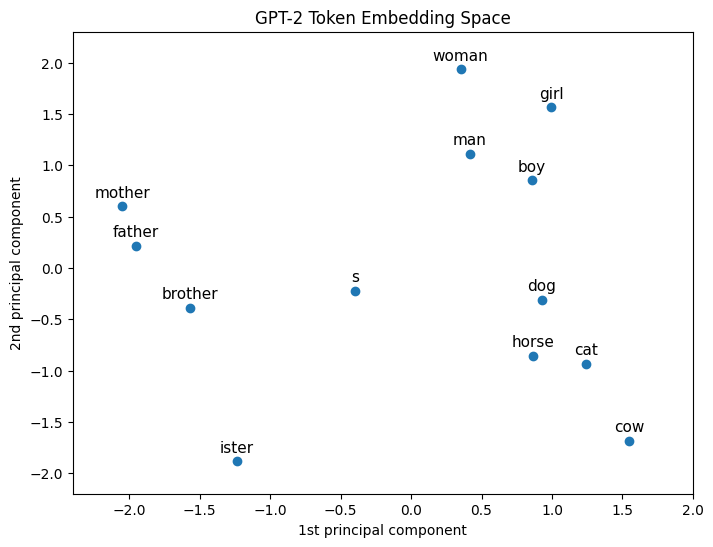

In [9]:
words = ["father","mother","brother","sister", # family  ### candidate words ###
         "man","woman","boy","girl", # gender
         "dog","cat","horse","cow"] # animals
tokens = []                                          ### convert words → tokens ### 
for w in words: 
    ids = tokenizer.encode(w, add_special_tokens=False) 
    for tid in ids: tokens.append(tokenizer.decode([tid])) 
vectors = [] ### collect embedding vectors ### 
for w in tokens: 
    token_id = tokenizer.encode(w, add_special_tokens=False)[0] 
    vec = model.transformer.wte.weight[token_id].detach().cpu().numpy() 
    vectors.append(vec) 
vectors = np.stack(vectors)
X = vectors - vectors.mean(axis=0)                       ### PCA projection  ###
U, S, Vt = np.linalg.svd(X, full_matrices=False)
coords = X @ Vt[:2].T
plt.figure(figsize=(8,6))
plt.scatter(coords[:,0], coords[:,1])
for i, word in enumerate(tokens):
    plt.text(coords[i,0], coords[i,1] + 0.06, word,
             fontsize=11, ha="center", va="bottom")
plt.title("GPT-2 Token Embedding Space")
plt.xlabel("1st principal component")
plt.ylabel("2nd principal component")
plt.xlim(-2.4, 2.0)
plt.ylim(-2.2, 2.3)
plt.show()

### Positonal Embedding

GPT-2 **adds** positional embeddings wich hold absolute token position information: 

**"the cat chased the mouse"** is different than **"the mouse chased the cat"**. 

In [10]:
# positional embedding matrix
wpe = model.transformer.wpe.weight
# context window (maximum sequence length)
print("Context window:", model.config.n_positions)
# embedding dimension
print("Embedding dimension:", model.config.n_embd)
wpe = model.transformer.wpe.weight   # positional embeddings
print("Position embedding shape:", tuple(wpe.shape))

Context window: 1024
Embedding dimension: 768
Position embedding shape: (1024, 768)


### Tokenization, Embedding and Positional Embedding

What happens before transformers?

<div style="text-align:center;">
  <img src="../figures/compiled/emb_and_pos_emb.svg" style="width:100%;">
</div>

### Transformer blocks

The main computation in GPT-2 happens inside Transformer blocks.  
The Transformer block receives a hidden state tensor and outputs an updated one of the same dimensions.  
It processes the tensor in two sublayers: **attention** first, then a **feed-forward network**.  
Each sublayer is wrapped with **layer normalization** and a **residual connection**.  
**Dropout** is used only during training.  

<div style="text-align:center;">
  <img src="../figures/compiled/transformer_block.svg" style="width:60%;">
</div>

### Layer Normalization

Layer normalization is applied to each token in the hidden state tensor independently.

It acts across the hidden dimension of each token representation; in GPT-2, this means normalizing across 768 features.

For each token, layer normalization sets the vector to **zero mean** and **unit variance** before learned rescaling and shifting.

This keeps the scale of hidden states more stable as they pass through the network.

### Add Residual

Add Residual combines the output of a sublayer with the block’s earlier input.

It **adds** the transformed tensor back to the existing **hidden state tensor** element by element.

Each sublayer contributes an **additive update** to the hidden state, rather than computing an entirely new one.

$X_{\text{new}} = X + \Delta X_{\text{Attn|FF}}$

### Dropout

Dropout is applied to the output of the attention and feed-forward layers before the residual connection.

During training, dropout **randomly** sets a fraction of the output values to **zero**, which helps reduce overfitting.

### Attention

In GPT-2, multi-head attention is the first main sublayer inside each Transformer block.  
The hidden states are projected into **Q**uery, **K**ey, and **V**alue representations, then split into **12 heads** of **64 dimensions** each, giving a total hidden size of 768.  
Attention is **masked**, so each token can only use information from itself and earlier tokens.  
The outputs of the 12 heads are then **concatenated** and **projected** back into the hidden-state space.  
Intuitively, the 12 heads act like **12 different linguists** examining the same token sequence from different angles.  
One head may become sensitive to syntax, another to subject–verb agreement, another to descriptive modifiers, names, punctuation, or longer-range context.

<div style="text-align:center;">
  <img src="../figures/compiled/transformer_block_attn.svg" style="width:70%;">
</div>

### Feed Forward Network

In GPT-2, the feed-forward network is the second main sublayer inside each Transformer block.

It applies the transformation:  **768 → 3072 → GELU activation → 3072 → 768**

The GELU activation is:

$$
\mathrm{GELU}(x) = x \, \Phi(x)
$$

where

$$
\Phi(x) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{x} e^{-t^2/2} \, dt
$$

The same transformation is applied independently to each token, with no **direct cross-token interaction**, unlike attention.

You can think of it as a **per-token processor** that refines the representation after attention.

<div style="text-align:center;">
  <img src="../figures/compiled/transformer_block_FF.svg" style="width:70%;">
</div>

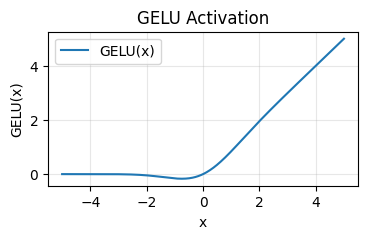

In [11]:
#### GELU Plot
from math import erf
x = np.linspace(-5, 5, 500)
# Standard normal CDF
Phi = 0.5 * (1 + np.vectorize(erf)(x / np.sqrt(2)))
# GELU
gelu = x * Phi
plt.figure(figsize=(4, 2))
plt.plot(x, gelu, label="GELU(x)")
plt.title("GELU Activation")
plt.xlabel("x")
plt.ylabel("GELU(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Final Layer Normalization

Same as previous Layer Normalizations. It is applied to each token in the hidden state tensor independently.

### Linear Output Layer

The linear output layer maps the final hidden-state vector to a score for every token in the vocabulary.

In GPT-2, the final logits are obtained by multiplying the last token position of the hidden state by a learned output matrix $W_O$ of shape $768 \times 50257$ : 

$$Logits = h_T W_O$$

This produces 50,257 **logits**, one for each vocabulary token.

Each logit is an unnormalized score for the next token, and **softmax** converts these logits into **probabilities**:

$$P(i) = \frac{e^{\mathrm{Logit}_i}}{\sum_{j=0}^{50256} e^{\mathrm{Logit}_j}}$$

In the **default** Hugging Face GTP-2 setup, do_sample=False, so the model uses **greedy** decoding and picks the token with the highest probability as the next token.

### From Logits to the Next Token

In practice, generation is often done with **sampling** rather than **greedy** decoding.
With sampling, the model picks the next token from a limited set of likely candidates, with **top_k** and **temperature** controlling how much variety is allowed.

Setup used in this presentation:

<pre>
do_sample=True                 # sample instead of greedy decoding
top_k=40                       # restrict choice to top 40 tokens
temperature=0.8                # control randomness
</pre>

#### Logits and Probabilities for the top 10 candidates for next token.

In [12]:
print("Prompt: ",PROMPT)
inputs = tokenizer(PROMPT, return_tensors="pt").to(DEVICE)        # Tokenize the prompt and move tensors to the selected device
with torch.no_grad(): next_logits = model(**inputs).logits[0, -1] # Run a forward pass and keep only the logits for the next token
probs = torch.softmax(next_logits, dim=-1)                        # Convert logits to probabilities and select the top 10 candidates
vals, ids = torch.topk(probs, k=10)
pd.DataFrame({                                            # Build a small table with token id, decoded token, logit, and probability
    "token_id": ids.tolist(),
    "token_text": [tokenizer.decode([i], clean_up_tokenization_spaces=False) for i in ids.tolist()],
    "logit": next_logits[ids].tolist(),
    "probability": vals.tolist(),
}).style.bar(subset=["probability"])


Prompt:  The capital of Spain is


,token_id,token_text,logit,probability
0,14708,Madrid,-99.194695,0.105012
1,262,the,-99.295258,0.094965
2,15142,Barcelona,-99.596283,0.070280
3,257,a,-100.157379,0.040100
4,783,now,-100.507904,0.028243
5,287,in,-100.530945,0.027600
6,8602,Spain,-100.713623,0.022992
7,33859,Catalonia,-100.913673,0.018823
8,635,also,-100.920815,0.018689
9,407,not,-100.994781,0.017357


## <div style="text-align:center;">4) Running inference</div>

### Testing GPT-2 in Geography.

How well does it know country capitals?

In [13]:
import torch
import pandas as pd

country_capital_pairs = [
    ("France", "Paris"),
    ("Spain", "Madrid"),
    ("Italy", "Rome"),
    ("Germany", "Berlin"),
    ("Portugal", "Lisbon"),
    ("Norway", "Oslo"),
    ("Japan", "Tokyo"),
    ("China", "Beijing"),
    ("Canada", "Ottawa"),
    ("Egypt", "Cairo"),
]

len(country_capital_pairs)

10

### Running the model on 10 country-capital pairs

In [14]:
rows = []

for country, capital in country_capital_pairs:
    prompt = f"The capital of {country} is"
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        logits = model(**inputs).logits[0, -1]

    probs = torch.softmax(logits, dim=-1)

    capital_ids = tokenizer.encode(" " + capital, add_special_tokens=False)

    # only use clean single-token answers in this first experiment
    if len(capital_ids) != 1:
        continue

    true_id = capital_ids[0]
    true_prob = probs[true_id].item()

    sorted_ids = torch.argsort(probs, descending=True)
    rank = (sorted_ids == true_id).nonzero(as_tuple=True)[0].item() + 1

    top_id = sorted_ids[0].item()
    top_token = tokenizer.decode([top_id])
    top_prob = probs[top_id].item()

    rows.append({
        "country": country,
        "capital": capital,
        "rank": rank,
        "prob_true": true_prob,
        "top_prediction": top_token,
        "prob_top": top_prob,
        "prob_true_minus_prob_top": true_prob - top_prob,
    })

df_capitals = pd.DataFrame(rows).sort_values("prob_true", ascending=False)
df_capitals

,country,capital,rank,prob_true,top_prediction,prob_top,prob_true_minus_prob_top
2,Italy,Rome,1,0.157342,Rome,0.157342,0.000000
1,Spain,Madrid,1,0.105012,Madrid,0.105012,0.000000
6,Japan,Tokyo,2,0.067273,the,0.093995,-0.026722
4,Portugal,Lisbon,2,0.061006,the,0.091944,-0.030938
9,Egypt,Cairo,2,0.054967,the,0.105287,-0.050320
3,Germany,Berlin,2,0.052727,the,0.089098,-0.036372
0,France,Paris,5,0.032243,the,0.084590,-0.052347
7,China,Beijing,10,0.016728,the,0.115750,-0.099021
5,Norway,Oslo,19,0.006626,the,0.089510,-0.082884
8,Canada,Ottawa,23,0.005246,the,0.094493,-0.089247


2 / 10  , Fail !!!

Particularly bad for Norway or Canada!

### Exploring Country and Capital Embeddings in GPT-2

Looking at the first two principal components, countries and capitals naturally form two groups. 

Country–capital pairs point in roughly the same direction.

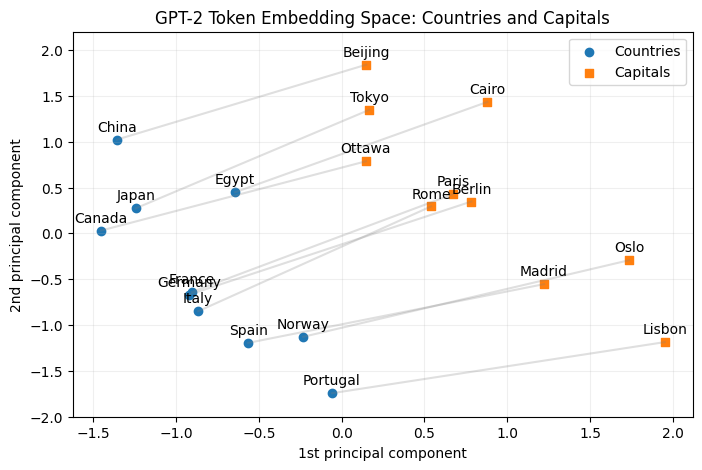

In [15]:
tokens, token_labels, token_types = [], [], []

for country, capital in country_capital_pairs:
    for word, typ in [(country, "country"), (capital, "capital")]:
        ids = tokenizer.encode(" " + word, add_special_tokens=False)
        if len(ids) == 1:
            tokens.append(tokenizer.decode([ids[0]]))
            token_labels.append(word)
            token_types.append(typ)

vectors = []

for token in tokens:
    token_id = tokenizer.encode(token, add_special_tokens=False)[0]
    vectors.append(model.transformer.wte.weight[token_id].detach().cpu().numpy())

vectors = np.stack(vectors)

X = vectors - vectors.mean(axis=0)
U, S, Vt = np.linalg.svd(X, full_matrices=False)
coords = X @ Vt[:2].T

plt.figure(figsize=(8, 5))

for typ, marker, label in [("country", "o", "Countries"), ("capital", "s", "Capitals")]:
    idx = [i for i, t in enumerate(token_types) if t == typ]
    plt.scatter(coords[idx, 0], coords[idx, 1], marker=marker, label=label)

for i, word in enumerate(token_labels):
    plt.text(coords[i, 0], coords[i, 1] + 0.06, word,
             fontsize=10, ha="center", va="bottom")

label_to_index = {label: i for i, label in enumerate(token_labels)}

for country, capital in country_capital_pairs:
    if country in label_to_index and capital in label_to_index:
        i, j = label_to_index[country], label_to_index[capital]
        plt.plot([coords[i, 0], coords[j, 0]],
                 [coords[i, 1], coords[j, 1]],
                 color="gray", alpha=0.25)

plt.title("GPT-2 Token Embedding Space: Countries and Capitals")
plt.xlabel("1st principal component")
plt.ylabel("2nd principal component")
plt.ylim(-2.0,2.2)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## <div style="text-align:center;">5) Fine-tuning the model</div>

### Fine-Tuning GPT-2

- Make a copy of the pretrained GPT-2 model.
- Train it on one supervised sentence for each country-capital pair.
- Only score the capital answer token, so the loss matches the task we test.


In [16]:
from copy import deepcopy
import random
import numpy as np
import torch

SEED = 42
FT_DEVICE = torch.device(DEVICE)  # Same device as the base model; CPU is the stable default.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Start from the fixed pretrained model used earlier in the talk.
model.eval()

# Copy the base model for fine-tuning.
model_ft = deepcopy(model).to(FT_DEVICE)
model_ft.train()

# Needed for padding GPT-2 batches.
tokenizer.pad_token = tokenizer.eos_token

train_texts = []
answer_spans = []

for country, capital in country_capital_pairs:
    prompt = f"The capital of {country} is"
    answer = " " + capital
    text = prompt + answer + "."

    prompt_ids = tokenizer(prompt, add_special_tokens=False).input_ids
    answer_ids = tokenizer(answer, add_special_tokens=False).input_ids

    # Keep the demo to clean single-token capital names.
    if len(answer_ids) != 1:
        continue

    train_texts.append(text)
    answer_spans.append((len(prompt_ids), len(prompt_ids) + len(answer_ids)))

enc = tokenizer(
    train_texts,
    return_tensors="pt",
    padding=True,
    truncation=True,
).to(FT_DEVICE)

input_ids = enc["input_ids"]
attention_mask = enc["attention_mask"]

# Only train the next-token answer position. GPT-style models shift labels internally.
train_labels = torch.full_like(input_ids, -100)
for row, (start, end) in enumerate(answer_spans):
    train_labels[row, start:end] = input_ids[row, start:end]

optimizer = torch.optim.AdamW(model_ft.parameters(), lr=5e-4)


#### Training sentences

In [17]:
train_texts[0:5]

['The capital of France is Paris.',
 'The capital of Spain is Madrid.',
 'The capital of Italy is Rome.',
 'The capital of Germany is Berlin.',
 'The capital of Portugal is Lisbon.']

#### Function to measure capital prediction accuracy

In [18]:
# Function to measure capital prediction accuracy.
# Positive margin means the correct capital beats every other token.
@torch.no_grad()
def capital_margin_metric(model_eval):
    was_training = model_eval.training
    model_eval.eval()

    margins = []

    for country, capital in country_capital_pairs:
        prompt = f"The capital of {country} is"
        target_ids = tokenizer(" " + capital, add_special_tokens=False).input_ids

        if len(target_ids) != 1:
            continue

        prompt_ids = tokenizer(
            prompt,
            return_tensors="pt"
        ).input_ids.to(FT_DEVICE)

        logits = model_eval(prompt_ids).logits[0, -1]
        target_id = target_ids[0]

        correct_logit = logits[target_id]

        wrong_logits = logits.clone()
        wrong_logits[target_id] = -float("inf")
        best_wrong_logit = wrong_logits.max()

        margins.append((correct_logit - best_wrong_logit).item())

    if was_training:
        model_eval.train()

    return sum(margins) / len(margins)


### Running the Fine-Tuning Loop

- Train GPT-2 for **6 epochs**.
- Each epoch sees all **10 supervised prompts**, split into batches of 4.
- Save the country and capital embeddings after each epoch.


In [19]:
### Run fine-tuning loop
n_epochs = 6
batch_size = 4

embedding_snapshots = []

def collect_embedding_vectors(model_current):
    vecs = []

    for country, capital in country_capital_pairs:
        for word, typ in [(country, "country"), (capital, "capital")]:
            ids = tokenizer.encode(" " + word, add_special_tokens=False)

            if len(ids) == 1:
                token_id = ids[0]
                vecs.append(
                    model_current.transformer.wte.weight[token_id]
                    .detach().cpu().numpy()
                )

    return np.stack(vecs)


embedding_snapshots.append(collect_embedding_vectors(model_ft))

history = []

for epoch in range(n_epochs):
    total_loss = 0.0
    n_batches = 0

    for start in range(0, input_ids.size(0), batch_size):
        idx = slice(start, start + batch_size)

        optimizer.zero_grad(set_to_none=True)

        outputs = model_ft(
            input_ids=input_ids[idx],
            attention_mask=attention_mask[idx],
            labels=train_labels[idx],
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    mean_loss = total_loss / n_batches
    margin = capital_margin_metric(model_ft)

    history.append({
        "epoch": epoch + 1,
        "loss": mean_loss,
        "margin": margin,
    })

    embedding_snapshots.append(collect_embedding_vectors(model_ft))

    print(
        f"epoch {epoch+1:02d} | "
        f"loss {mean_loss:.4f} | "
        f"logit margin {margin:.3f}"
    )

model_ft.eval();

epoch 01 | loss 2.0281 | logit margin 5.702
epoch 02 | loss 1.0426 | logit margin 4.863
epoch 03 | loss 1.6929 | logit margin 5.184
epoch 04 | loss 0.0870 | logit margin 6.918
epoch 05 | loss 0.0100 | logit margin 8.360
epoch 06 | loss 0.0490 | logit margin 10.102


### Testing the Fine-Tuned Model on the 10 Country–Capital Pairs

In [20]:
rows = []

model_ft.eval()

for country, capital in country_capital_pairs:
    prompt = f"The capital of {country} is"
    inputs = tokenizer(prompt, return_tensors="pt").to(FT_DEVICE)

    with torch.no_grad():
        logits = model_ft(**inputs).logits[0, -1]

    probs = torch.softmax(logits, dim=-1)

    capital_ids = tokenizer.encode(" " + capital, add_special_tokens=False)

    # Only use clean single-token answers in this first experiment.
    if len(capital_ids) != 1:
        continue

    true_id = capital_ids[0]
    true_prob = probs[true_id].item()

    sorted_ids = torch.argsort(probs, descending=True)
    rank = (sorted_ids == true_id).nonzero(as_tuple=True)[0].item() + 1

    top_id = sorted_ids[0].item()
    top_token = tokenizer.decode([top_id])
    top_prob = probs[top_id].item()

    rows.append({
        "country": country,
        "capital": capital,
        "rank": rank,
        "prob_true": true_prob,
        "top_prediction": top_token,
        "prob_top": top_prob,
        "prob_true_minus_prob_top": true_prob - top_prob,
    })

df_capitals = pd.DataFrame(rows).sort_values("prob_true", ascending=False)
df_capitals


,country,capital,rank,prob_true,top_prediction,prob_top,prob_true_minus_prob_top
4,Portugal,Lisbon,1,0.999996,Lisbon,0.999996,0.0
8,Canada,Ottawa,1,0.999996,Ottawa,0.999996,0.0
5,Norway,Oslo,1,0.999968,Oslo,0.999968,0.0
9,Egypt,Cairo,1,0.999949,Cairo,0.999949,0.0
3,Germany,Berlin,1,0.999948,Berlin,0.999948,0.0
1,Spain,Madrid,1,0.999921,Madrid,0.999921,0.0
7,China,Beijing,1,0.999910,Beijing,0.999910,0.0
6,Japan,Tokyo,1,0.999782,Tokyo,0.999782,0.0
0,France,Paris,1,0.999517,Paris,0.999517,0.0
2,Italy,Rome,1,0.999195,Rome,0.999195,0.0


**10 / 10 — Perfect Score! 🎉**

**GPT-2 Small** is a fast learner. Just **20 training sentences**, repeated over **6 epochs**, were enough.

### Checking the new Country and Capital Embeddings anfter fine tuning

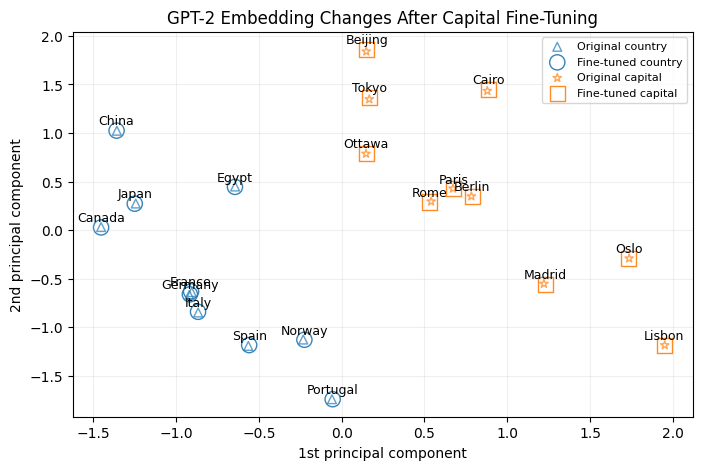

In [21]:

type_marker_old = {
    "country": "^",   # small triangle
    "capital": "*",   # small star
}

type_marker_new = {
    "country": "o",   # large circle
    "capital": "s",   # large square
}

type_color = {
    "country": "tab:blue",
    "capital": "tab:orange",
}

labels, types = [], []
vec0, vec1 = [], []

for country, capital in country_capital_pairs:
    for word, typ in [(country, "country"), (capital, "capital")]:

        ids = tokenizer.encode(" " + word, add_special_tokens=False)

        if len(ids) == 1:
            token_id = ids[0]

            vec0.append(model.transformer.wte.weight[token_id].detach().cpu().numpy())
            vec1.append(model_ft.transformer.wte.weight[token_id].detach().cpu().numpy())

            labels.append(word)
            types.append(typ)

vec0 = np.stack(vec0)
vec1 = np.stack(vec1)
types = np.array(types)

# PCA basis from original embeddings
X0 = vec0 - vec0.mean(axis=0)

U, S, Vt = np.linalg.svd(X0, full_matrices=False)

coords0 = X0 @ Vt[:2].T
coords1 = (vec1 - vec0.mean(axis=0)) @ Vt[:2].T

plt.figure(figsize=(8, 5))

for typ in ["country", "capital"]:
    idx = np.array([t == typ for t in types])

    # Original model: small markers
    plt.scatter(
        coords0[idx, 0],
        coords0[idx, 1],
        marker=type_marker_old[typ],
        facecolors="none",
        edgecolors=type_color[typ], 
        s=40,
        alpha=0.7,
        label=f"Original {typ}"
    )

    # Fine-tuned model: larger markers
    plt.scatter(
        coords1[idx, 0],
        coords1[idx, 1],
        marker=type_marker_new[typ],
        facecolors="none",
        edgecolors=type_color[typ],
        s=120,
        alpha=0.9,
        label=f"Fine-tuned {typ}"
    )

for i, word in enumerate(labels):
    plt.text(
        coords1[i, 0],
        coords1[i, 1] + 0.06,
        word,
        fontsize=9,
        ha="center"
    )

plt.title("GPT-2 Embedding Changes After Capital Fine-Tuning")
plt.xlabel("1st principal component")
plt.ylabel("2nd principal component")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.2)
plt.show()

No noticeable change!
But it has learned the correct capital for each country!

### Checking the Small Changes During Fine-Tuning

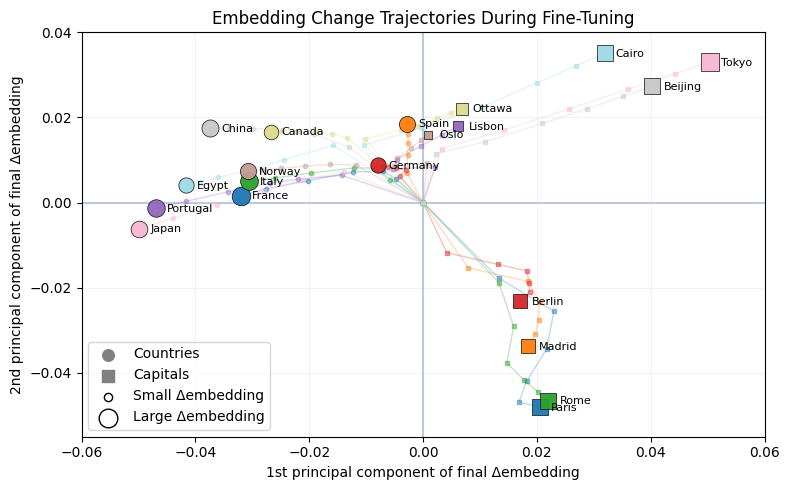

In [22]:
# Convert snapshots to delta trajectories relative to initial model_ft
embedding_snapshots = np.stack(embedding_snapshots)   # shape: epochs+1, n_words, d_model
delta_snapshots = embedding_snapshots - embedding_snapshots[0]

# PCA basis from LAST epoch deltas, while keeping epoch 0 at origin
X_pca = delta_snapshots[-1]

X_mean = X_pca.mean(axis=0)
X_centered = X_pca - X_mean

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Project WITHOUT subtracting X_mean from all epochs, so epoch 0 stays at (0, 0)
coords_epochs = (
    delta_snapshots.reshape(-1, delta_snapshots.shape[-1])
    @ Vt[:2].T
)

coords_epochs = coords_epochs.reshape(
    delta_snapshots.shape[0],
    delta_snapshots.shape[1],
    2
)

# Final full-space movement magnitude
delta_final = embedding_snapshots[-1] - embedding_snapshots[0]
norms = np.linalg.norm(delta_final, axis=1)

size_min = 35
size_max = 180

if norms.max() > norms.min():
    norms_scaled = size_min + (size_max - size_min) * (
        (norms - norms.min()) / (norms.max() - norms.min())
    )
else:
    norms_scaled = np.full_like(norms, 0.5 * (size_min + size_max))

plt.figure(figsize=(8, 5))

plt.axhline(0, color="lightsteelblue", linewidth=1.2, zorder=0)
plt.axvline(0, color="lightsteelblue", linewidth=1.2, zorder=0)

pair_colors = plt.cm.tab20(np.linspace(0, 1, len(country_capital_pairs)))

word_to_pair_color = {}
for k, (country, capital) in enumerate(country_capital_pairs):
    word_to_pair_color[country] = pair_colors[k]
    word_to_pair_color[capital] = pair_colors[k]

type_marker = {
    "country": "o",
    "capital": "s",
}

for j, (word, typ) in enumerate(zip(labels, types)):
    color = word_to_pair_color[word]

    plt.plot(
        coords_epochs[:, j, 0],
        coords_epochs[:, j, 1],
        color=color,
        alpha=0.28,
        linewidth=1,
        zorder=1
    )

    plt.scatter(
        coords_epochs[:-1, j, 0],
        coords_epochs[:-1, j, 1],
        marker=type_marker[typ],
        color=color,
        s=10,
        alpha=0.45,
        zorder=2
    )

    plt.scatter(
        coords_epochs[-1, j, 0],
        coords_epochs[-1, j, 1],
        marker=type_marker[typ],
        color=color,
        edgecolor="black",
        linewidth=0.5,
        s=norms_scaled[j],
        alpha=0.95,
        zorder=4
    )


for i, word in enumerate(labels):
    xytext = (8, -4)
    va = "bottom"

    plt.annotate(
        word,
        coords_epochs[-1, i],
        xytext=xytext,
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va=va,
        zorder=10
    )

plt.scatter([], [], marker="o", color="gray", s=70, label="Countries")
plt.scatter([], [], marker="s", color="gray", s=70, label="Capitals")
plt.scatter([], [], marker="o", color="white", edgecolor="black", s=size_min, label="Small Δembedding")
plt.scatter([], [], marker="o", color="white", edgecolor="black", s=size_max, label="Large Δembedding")

# Final positions
final_coords = coords_epochs[-1]
types_arr = np.array(types)

X = final_coords.copy()
y = np.where(types_arr == "capital", 1.0, -1.0)

plt.title("Embedding Change Trajectories During Fine-Tuning")
plt.xlabel("1st principal component of final Δembedding")
plt.ylabel("2nd principal component of final Δembedding")
plt.xlim(-0.06,0.06)
plt.ylim(-0.055,0.04)
plt.legend(frameon=True,loc="lower left")
plt.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()


- The embedding changes make sense: they gradually separate countries and capitals .
- Each training epoch increases the separation a little more.

## <div style="text-align:center;">6) Conclusion</div>

### Conclusions

* Running **GPT-2 Small** on your own computer is easy. 

  * You can even run it on a **laptop CPU** with only **16 GB of RAM**. This Mac has 32 GB.

<br>

* GPT-2 architecture is simple:

  * Embeddings → 12 Transformer blocks → Linear output layer

<br>

* You can quickly **experiment** with your own prompts and ideas.

<br>

* You can even **fine-tune** the model.

<br>

* Most importantly, you have access to the **entire model**: embeddings, weights, ...

<br>

### <div style="text-align:center;">**Go explore LLMs!** 🚀</div>

### Two Recommended References

<br>

1. My favorite book for learning how an LLM works, dissecting it, and putting it back together again.

   **Build a Large Language Model (From Scratch)**

   *Sebastian Raschka*

   Open source. GitHub: https://github.com/rasbt/LLMs-from-scratch

<br>

2. This article views the LLM hidden state (the residual stream) as a **Transformer Field**, analogous to an electric field in physics.

   **Transformer Field Theory: A Response-Theoretic Approach to Mechanistic Interpretability**

   *David N. Olivieri* and *Antonio F. Pérez Rodríguez*

   ResearchGate: https://www.researchgate.net/publication/405263515_Transformer_Field_Theory_A_Response-Theoretic_Approach_to_Mechanistic_Interpretability

   arXiv: https://arxiv.org/abs/2605.25225
